# 4. Feature Engineering

В этом ноутбуке мы строим полный пайплайн преобразования признаков для задачи предсказания цены подержанного автомобиля.

**Важно:** все трансформеры (scaler, target encoder, статистики) обучаются **только** на тренировочных данных, что исключает утечку данных (Data Leakage).

---

## Содержание

1. [Загрузка данных](#section-1)
2. [Базовые преобразования](#section-2) — car_age, log_odometer, log_price
3. [Обработка цилиндров](#section-3)
4. [Заполнение пропусков и группировка редких категорий](#section-4)
5. [One-Hot Encoding](#section-5)
6. [Target Encoding (только на train)](#section-6)
7. [Региональные и производительские статистики (только на train)](#section-7)
8. [Интерактивные признаки](#section-8)
9. [Скейлинг (только на train)](#section-9)
10. [Отбор признаков (только на train)](#section-10)
11. [Сохранение результатов](#section-11)

<a id='section-1'></a>
## 1. Загрузка данных и библиотек

In [3]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy.stats import skew

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

CURRENT_YEAR = 2022

print("Библиотеки загружены")

Библиотеки загружены


In [4]:
# Обучающие данные (уже отфильтрованные в EDA)
df_train = pd.read_csv('data/interim/train_filtered.csv', index_col=0)

# Тестовые данные — применяем те же фильтры, что и при EDA
df_test_raw = pd.read_csv('data/interim/test.csv', index_col=0)
df_test_raw = df_test_raw[
    (df_test_raw['year'] >= 1980) &
    (df_test_raw['odometer'] > 0) & (df_test_raw['odometer'] <= 500_000) &
    (df_test_raw['price'] >= 500) & (df_test_raw['price'] <= 100_000)
].copy()

print(f"Train: {df_train.shape}")
print(f"Test (после фильтрации): {df_test_raw.shape}")
print(f"\nКолонки: {df_train.columns.tolist()}")

# Сохраним сырые тестовые данные для анализа ошибок
test_raw = df_test_raw.copy()

Train: (182152, 19)
Test (после фильтрации): (78106, 19)

Колонки: ['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'description', 'state', 'lat', 'long', 'posting_date']


In [5]:
# Разделяем признаки и целевую переменную
X_train = df_train.drop(columns=['price']).copy()
y_train = df_train['price'].copy()
y_train_log = np.log1p(y_train)     # логарифм цены — целевая для обучения

X_test = df_test_raw.drop(columns=['price']).copy()
y_test = df_test_raw['price'].copy()
y_test_log = np.log1p(y_test)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test: {y_test.shape}")
print(f"\nЦелевая переменная (log_price):")
print(f"  Train — mean={y_train_log.mean():.3f}, std={y_train_log.std():.3f}")
print(f"  Test  — mean={y_test_log.mean():.3f},  std={y_test_log.std():.3f}")

X_train: (182152, 18), y_train: (182152,)
X_test:  (78106, 18),  y_test: (78106,)

Целевая переменная (log_price):
  Train — mean=9.440, std=0.909
  Test  — mean=9.443,  std=0.907


<a id='section-2'></a>
## 2. Базовые преобразования

### 2.1 Возраст автомобиля (`car_age`)

Год выпуска в абсолютном выражении менее информативен, чем **возраст автомобиля**.
Формула: `car_age = CURRENT_YEAR - year`

Пропуски в `year` заполняем **модой тренировочной выборки**.

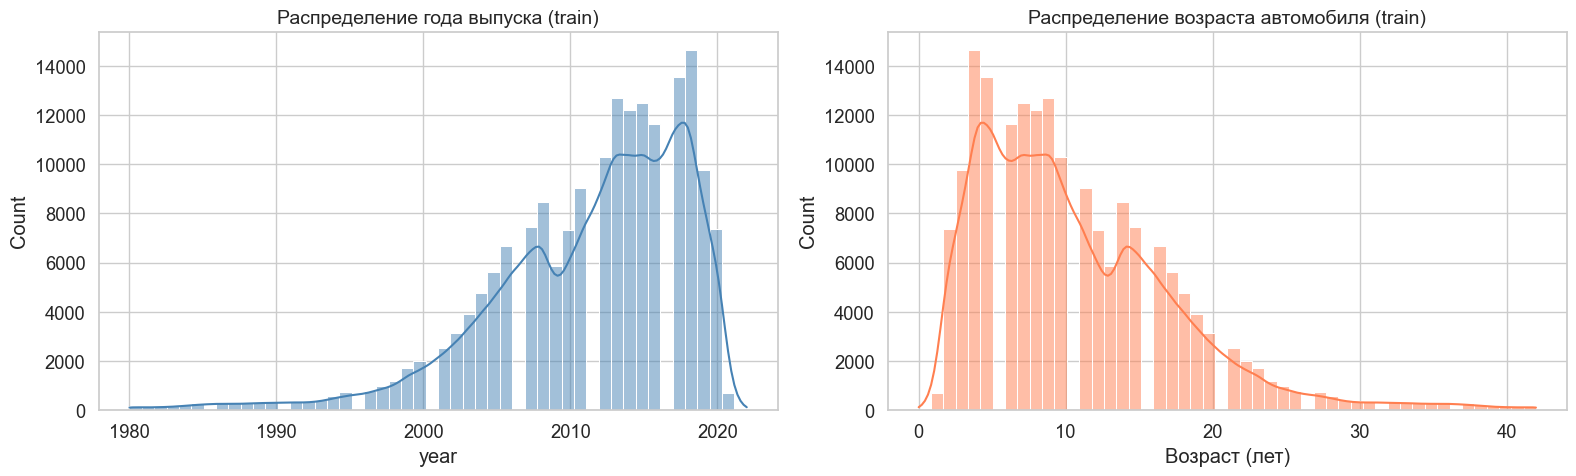

car_age — статистика (train):
count    182152.00
mean         10.67
std           6.77
min           0.00
25%           5.00
50%           9.00
75%          15.00
max          42.00
Name: car_age, dtype: float64


In [6]:
# Мода считается только на train!
year_mode = X_train['year'].mode()[0]

X_train['year'] = X_train['year'].fillna(year_mode)
X_test['year']  = X_test['year'].fillna(year_mode)

X_train['car_age'] = CURRENT_YEAR - X_train['year']
X_test['car_age']  = CURRENT_YEAR - X_test['year']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(X_train['year'],    bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение года выпуска (train)', fontsize=14)

sns.histplot(X_train['car_age'], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Распределение возраста автомобиля (train)', fontsize=14)
axes[1].set_xlabel('Возраст (лет)')

plt.tight_layout()
plt.show()

print(f"car_age — статистика (train):\n{X_train['car_age'].describe().round(2)}")

### 2.2 Логарифм пробега (`log_odometer`)

Распределение `odometer` имеет сильную правостороннюю асимметрию (long right tail).
Логарифм нормализует распределение и уменьшает влияние выбросов.

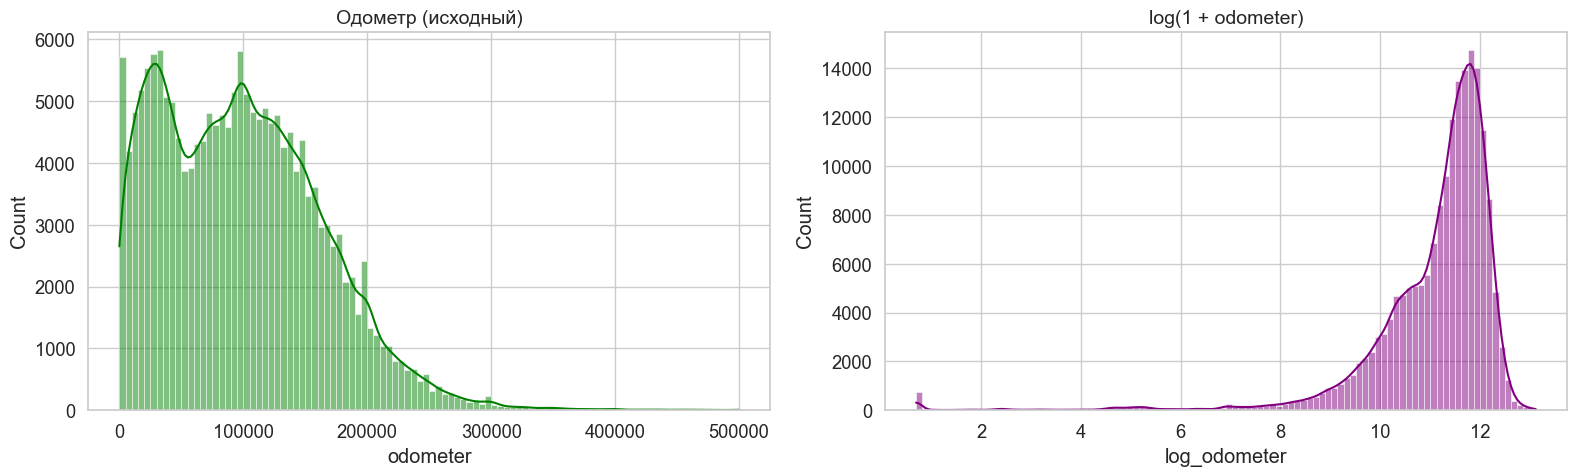

Асимметрия одометра: 0.69 → -3.68


In [7]:
# Среднее одометра считается только на train!
odo_mean = X_train['odometer'].mean()

X_train['odometer'] = X_train['odometer'].fillna(odo_mean)
X_test['odometer']  = X_test['odometer'].fillna(odo_mean)

X_train['log_odometer'] = np.log1p(X_train['odometer'])
X_test['log_odometer']  = np.log1p(X_test['odometer'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(X_train['odometer'],     bins=100, kde=True, ax=axes[0], color='green')
axes[0].set_title('Одометр (исходный)', fontsize=14)

sns.histplot(X_train['log_odometer'], bins=100, kde=True, ax=axes[1], color='purple')
axes[1].set_title('log(1 + odometer)', fontsize=14)

plt.tight_layout()
plt.show()

skew_before = skew(X_train['odometer'])
skew_after  = skew(X_train['log_odometer'])
print(f"Асимметрия одометра: {skew_before:.2f} → {skew_after:.2f}")

### 2.3 Логарифм цены (`log_price` — целевая переменная)

Обучаем модели предсказывать `log(1 + price)`, а при инференсе применяем `expm1`.
Это нормализует распределение остатков и улучшает качество моделей.

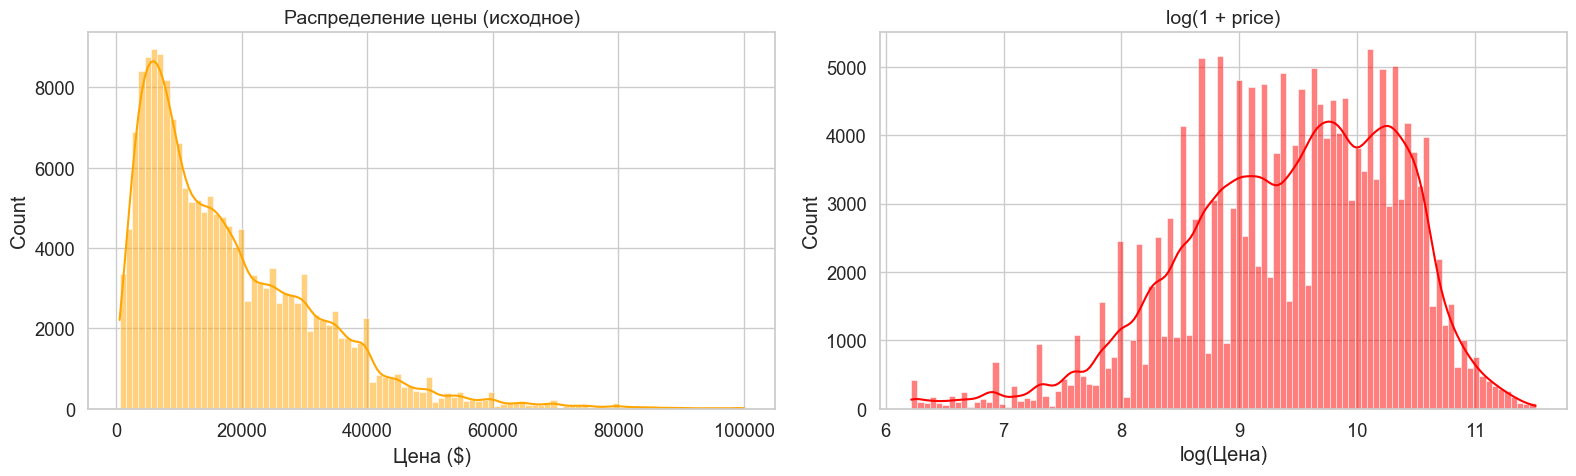

Асимметрия цены: 1.39 → -0.59


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(y_train,     bins=100, kde=True, ax=axes[0], color='orange')
axes[0].set_title('Распределение цены (исходное)', fontsize=14)
axes[0].set_xlabel('Цена ($)')

sns.histplot(y_train_log, bins=100, kde=True, ax=axes[1], color='red')
axes[1].set_title('log(1 + price)', fontsize=14)
axes[1].set_xlabel('log(Цена)')

plt.tight_layout()
plt.show()

print(f"Асимметрия цены: {skew(y_train):.2f} → {skew(y_train_log):.2f}")

<a id='section-3'></a>
## 3. Обработка цилиндров

Признак `cylinders` хранится как текст ("4 cylinders"). Преобразуем в числовой формат.

In [9]:
CYLINDERS_MAP = {
    "3 cylinders": 3, "4 cylinders": 4, "5 cylinders": 5,
    "6 cylinders": 6, "8 cylinders": 8, "10 cylinders": 10,
    "12 cylinders": 12, "other": 0
}

for df_ in [X_train, X_test]:
    df_['cylinders'] = df_['cylinders'].fillna('other')
    df_['cylinders_num']        = df_['cylinders'].map(CYLINDERS_MAP).fillna(0).astype(int)
    df_['cylinders_other_flag'] = (df_['cylinders'] == 'other').astype(int)

print("Распределение цилиндров (train):")
print(X_train['cylinders_num'].value_counts().sort_index())

Распределение цилиндров (train):
cylinders_num
0     69614
3       311
4     37059
5       937
6     43061
8     30469
10      610
12       91
Name: count, dtype: int64


<a id='section-4'></a>
## 4. Заполнение пропусков и группировка редких категорий

### 4.1 Заполнение пропусков в категориальных признаках

In [10]:
CAT_COLS = ['condition', 'drive', 'transmission', 'fuel',
            'manufacturer', 'title_status', 'type', 'model']

missing_before = X_train[CAT_COLS].isnull().sum()
print("Пропуски до заполнения:")
print(missing_before[missing_before > 0])

for col in CAT_COLS:
    X_train[col] = X_train[col].fillna('unknown')
    X_test[col]  = X_test[col].fillna('unknown')

print("\nПропуски после заполнения:")
print(X_train[CAT_COLS].isnull().sum().sum(), "— нет пропусков")

Пропуски до заполнения:
condition       64541
drive           52625
transmission      723
fuel              898
manufacturer     6154
title_status     2416
type            40792
model            2016
dtype: int64

Пропуски после заполнения:
0 — нет пропусков


### 4.2 Группировка редких категорий

Категории с малым числом вхождений переводим в `'other'`.
**Порог определяется только по train**, чтобы исключить утечку данных.

In [11]:
def group_rare_categories(s_train, s_test, min_count=20):
    """Группирует редкие категории в 'other'. Порог определяется по train."""
    rare = s_train.value_counts()[lambda x: x < min_count].index
    s_train = s_train.copy()
    s_test  = s_test.copy()
    s_train[s_train.isin(rare)] = 'other'
    s_test[s_test.isin(rare)]   = 'other'
    return s_train, s_test

n_before = X_train['model'].nunique()
X_train['model_grouped'], X_test['model_grouped'] = group_rare_categories(
    X_train['model'], X_test['model'], min_count=20
)
print(f"model: {n_before} → {X_train['model_grouped'].nunique()} уникальных значений")

n_before = X_train['manufacturer'].nunique()
if n_before > 50:
    X_train['manufacturer_grouped'], X_test['manufacturer_grouped'] = group_rare_categories(
        X_train['manufacturer'], X_test['manufacturer'], min_count=100
    )
else:
    X_train['manufacturer_grouped'] = X_train['manufacturer']
    X_test['manufacturer_grouped']  = X_test['manufacturer']
print(f"manufacturer: {n_before} → {X_train['manufacturer_grouped'].nunique()} уникальных значений")

model: 20175 → 1367 уникальных значений
manufacturer: 43 → 43 уникальных значений


<a id='section-5'></a>
## 5. One-Hot Encoding

Применяем OHE к признакам с **небольшим числом категорий** (< 15).
Высококардинальные признаки (`model`, `manufacturer`, `region`) обработаем Target Encoding.

In [12]:
LOW_CARD_COLS = ['condition', 'transmission', 'drive', 'fuel', 'title_status', 'type']

print("Кардинальность признаков перед OHE:")
for col in LOW_CARD_COLS:
    print(f"  {col}: {X_train[col].nunique()} уникальных значений")

X_train_ohe = pd.get_dummies(X_train, columns=LOW_CARD_COLS,
                              prefix=LOW_CARD_COLS, drop_first=False, dtype=int)
X_test_ohe  = pd.get_dummies(X_test,  columns=LOW_CARD_COLS,
                              prefix=LOW_CARD_COLS, drop_first=False, dtype=int)

# Выравниваем колонки теста по трейну (категории, которых нет в тесте — добавляем нулями)
X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

print(f"\nРазмерность до OHE:    {X_train.shape}")
print(f"Размерность после OHE: {X_train_ohe.shape}")
print(f"Добавлено признаков: {X_train_ohe.shape[1] - X_train.shape[1]}")

Кардинальность признаков перед OHE:
  condition: 7 уникальных значений
  transmission: 4 уникальных значений
  drive: 4 уникальных значений
  fuel: 6 уникальных значений
  title_status: 7 уникальных значений
  type: 14 уникальных значений

Размерность до OHE:    (182152, 24)
Размерность после OHE: (182152, 60)
Добавлено признаков: 36


<a id='section-6'></a>
## 6. Target Encoding для высококардинальных признаков

**Target Encoding** заменяет каждую категорию средним значением `log(price)` для неё.

Используем **сглаживание** (smoothing), чтобы редкие категории не переобучались:
$$\hat{v} = \frac{n \cdot \bar{y}_{cat} + k \cdot \bar{y}_{global}}{n + k}$$

**Важно:** статистики вычисляются ТОЛЬКО на train, test получает только transform.

In [13]:
HIGH_CARD_COLS = ['manufacturer_grouped', 'model_grouped', 'region']

global_mean_log = y_train_log.mean()  # глобальное среднее — только по train
SMOOTHING = 20

target_encoders = {}  # сохраним маппинги для документирования

for col in HIGH_CARD_COLS:
    if col not in X_train_ohe.columns:
        continue

    # Статистики ТОЛЬКО по train
    temp = pd.DataFrame({'cat': X_train_ohe[col], 'target': y_train_log.values},
                         index=X_train_ohe.index)
    stats = temp.groupby('cat')['target'].agg(['mean', 'count'])
    stats['smoothed'] = (
        stats['mean'] * stats['count'] + SMOOTHING * global_mean_log
    ) / (stats['count'] + SMOOTHING)
    mapping = stats['smoothed'].to_dict()
    target_encoders[col] = mapping

    X_train_ohe[f'{col}_target'] = X_train_ohe[col].map(mapping).fillna(global_mean_log)
    X_test_ohe[f'{col}_target']  = X_test_ohe[col].map(mapping).fillna(global_mean_log)

    print(f"Target encoded: {col} — {len(mapping)} категорий")

print(f"\nГлобальное среднее log(price) по train: {global_mean_log:.4f}")

Target encoded: manufacturer_grouped — 43 категорий
Target encoded: model_grouped — 1367 категорий
Target encoded: region — 404 категорий

Глобальное среднее log(price) по train: 9.4400


<a id='section-7'></a>
## 7. Статистики по регионам и производителям

Добавляем агрегированные ценовые статистики по регионам и производителям.
**Все статистики вычислены на тренировочных данных** — test получает только результат merge.

In [14]:
# Статистики по регионам (fit на train)
region_stats = (
    X_train_ohe[['region']].join(y_train.rename('price'))
    .groupby('region')['price']
    .agg(['mean', 'median', 'std'])
    .rename(columns={'mean': 'region_mean_price',
                     'median': 'region_median_price',
                     'std': 'region_price_std'})
)

global_region = region_stats.mean()  # для заполнения неизвестных регионов в тесте

X_train_ohe = X_train_ohe.join(region_stats, on='region')
X_test_ohe  = X_test_ohe.join(region_stats, on='region')

for col in ['region_mean_price', 'region_median_price', 'region_price_std']:
    X_train_ohe[col] = X_train_ohe[col].fillna(global_region[col])
    X_test_ohe[col]  = X_test_ohe[col].fillna(global_region[col])

print(f"Количество уникальных регионов: {len(region_stats)}")
print("\nТоп-10 дорогих регионов:")
print(region_stats.nlargest(10, 'region_mean_price')['region_mean_price'].round(0))

Количество уникальных регионов: 404

Топ-10 дорогих регионов:
region
moses lake          35756.0
east oregon         34088.0
logan               33135.0
salt lake city      33048.0
southwest TX        32412.0
pullman / moscow    32355.0
boone               32262.0
butte               31770.0
northwest KS        30273.0
kirksville          30165.0
Name: region_mean_price, dtype: float64


In [15]:
# Статистики по производителям (fit на train)
manuf_stats = (
    X_train_ohe[['manufacturer']].join(y_train.rename('price'))
    .groupby('manufacturer')['price']
    .agg(['mean', 'median', 'std'])
    .rename(columns={'mean': 'manuf_mean_price',
                     'median': 'manuf_median_price',
                     'std': 'manuf_price_std'})
)

global_manuf = manuf_stats.mean()

X_train_ohe = X_train_ohe.join(manuf_stats, on='manufacturer')
X_test_ohe  = X_test_ohe.join(manuf_stats, on='manufacturer')

for col in ['manuf_mean_price', 'manuf_median_price', 'manuf_price_std']:
    X_train_ohe[col] = X_train_ohe[col].fillna(global_manuf[col])
    X_test_ohe[col]  = X_test_ohe[col].fillna(global_manuf[col])

print("Топ-10 дорогих производителей:")
print(manuf_stats.nlargest(10, 'manuf_mean_price')['manuf_mean_price'].round(0))

Топ-10 дорогих производителей:
manufacturer
ferrari         76482.0
aston-martin    54524.0
tesla           40560.0
porsche         31747.0
alfa-romeo      29372.0
ram             28670.0
rover           27820.0
jaguar          25409.0
gmc             24182.0
audi            23960.0
Name: manuf_mean_price, dtype: float64


<a id='section-8'></a>
## 8. Полиномиальные и интерактивные признаки

Нелинейные взаимодействия помогают захватить, например, что старые автомобили с большим пробегом теряют ценность быстрее.

In [16]:
for df_ in [X_train_ohe, X_test_ohe]:
    df_['car_age_squared']        = df_['car_age'] ** 2
    df_['log_odometer_squared']   = df_['log_odometer'] ** 2
    df_['age_x_odometer']         = df_['car_age'] * df_['log_odometer']
    df_['age_x_cylinders']        = df_['car_age'] * df_['cylinders_num']
    df_['odometer_x_cylinders']   = df_['log_odometer'] * df_['cylinders_num']
    df_['mileage_per_year']        = df_['odometer'] / (df_['car_age'] + 1)
    df_['log_mileage_per_year']    = np.log1p(df_['mileage_per_year'])

new_features = [
    'car_age_squared', 'log_odometer_squared', 'age_x_odometer',
    'age_x_cylinders', 'odometer_x_cylinders', 'log_mileage_per_year'
]
print("Добавлены интерактивные признаки:")
for f in new_features:
    print(f"  {f}")
print(f"\nТекущая размерность: {X_train_ohe.shape}")

Добавлены интерактивные признаки:
  car_age_squared
  log_odometer_squared
  age_x_odometer
  age_x_cylinders
  odometer_x_cylinders
  log_mileage_per_year

Текущая размерность: (182152, 76)


### Удаление исходных колонок

Убираем исходные/технические колонки, из которых уже извлечены признаки.

In [17]:
COLS_TO_DROP = [
    'year', 'odometer', 'lat', 'long', 'region', 'manufacturer',
    'model', 'cylinders', 'manufacturer_grouped', 'model_grouped',
    'mileage_per_year', 'description', 'state', 'paint_color', 'posting_date'
]

X_train_fe = X_train_ohe.drop(columns=[c for c in COLS_TO_DROP if c in X_train_ohe.columns])
X_test_fe  = X_test_ohe.drop(columns=[c for c in COLS_TO_DROP if c in X_test_ohe.columns])

# Убедимся, что обе матрицы имеют одинаковые колонки
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=0)

print(f"Размерность после удаления исходных колонок:")
print(f"  X_train_fe: {X_train_fe.shape}")
print(f"  X_test_fe:  {X_test_fe.shape}")
print(f"\nПропуски в X_train_fe: {X_train_fe.isnull().sum().sum()}")
print(f"Пропуски в X_test_fe:  {X_test_fe.isnull().sum().sum()}")

Размерность после удаления исходных колонок:
  X_train_fe: (182152, 61)
  X_test_fe:  (78106, 61)

Пропуски в X_train_fe: 0
Пропуски в X_test_fe:  0


<a id='section-9'></a>
## 9. Скейлинг числовых признаков

`StandardScaler` приводит числовые признаки к нулевому среднему и единичной дисперсии.

**Критически важно:** `scaler.fit()` вызывается ТОЛЬКО на тренировочных данных.
Тест проходит только через `scaler.transform()`.

In [18]:
NUMERICAL_COLS_TO_SCALE = [
    'car_age', 'log_odometer', 'cylinders_num', 'cylinders_other_flag',
    'car_age_squared', 'log_odometer_squared',
    'age_x_odometer', 'age_x_cylinders', 'odometer_x_cylinders',
    'log_mileage_per_year',
    'region_mean_price', 'region_median_price', 'region_price_std',
    'manuf_mean_price', 'manuf_median_price', 'manuf_price_std',
    'manufacturer_grouped_target', 'model_grouped_target', 'region_target'
]

cols_to_scale = [c for c in NUMERICAL_COLS_TO_SCALE if c in X_train_fe.columns]
print(f"Признаков для скейлинга: {len(cols_to_scale)}")

scaler = StandardScaler()

# fit ТОЛЬКО на train!
X_train_fe[cols_to_scale] = scaler.fit_transform(X_train_fe[cols_to_scale])
X_test_fe[cols_to_scale]  = scaler.transform(X_test_fe[cols_to_scale])

X_train_scaled = X_train_fe
X_test_scaled  = X_test_fe

print(f"\nПример — car_age после скейлинга (train):")
print(f"  среднее = {X_train_scaled['car_age'].mean():.4f} (ожидается ~0)")
print(f"  std     = {X_train_scaled['car_age'].std():.4f}  (ожидается ~1)")

Признаков для скейлинга: 19

Пример — car_age после скейлинга (train):
  среднее = -0.0000 (ожидается ~0)
  std     = 1.0000  (ожидается ~1)


<a id='section-10'></a>
## 10. Отбор признаков

Используем `SelectKBest(f_regression)` для выбора наиболее значимых признаков.
Корреляция с log(price) — дополнительная проверка.

Все вычисления — ТОЛЬКО на train.

In [19]:
X_train_clean = X_train_scaled.fillna(0)
X_test_clean  = X_test_scaled.fillna(0)
X_test_clean  = X_test_clean.reindex(columns=X_train_clean.columns, fill_value=0)

# Корреляция с целевой переменной
corr = X_train_clean.corrwith(y_train_log).abs().sort_values(ascending=False)

print("Топ-15 признаков по |корреляции| с log(price):")
print(corr.head(15).round(3).to_string())

Топ-15 признаков по |корреляции| с log(price):
age_x_odometer                 0.608
car_age                        0.598
model_grouped_target           0.547
car_age_squared                0.463
log_odometer_squared           0.442
log_odometer                   0.350
age_x_cylinders                0.307
transmission_other             0.306
manufacturer_grouped_target    0.300
manuf_mean_price               0.290
manuf_median_price             0.286
fuel_gas                       0.263
condition_fair                 0.251
region_target                  0.245
region_mean_price              0.234


Выбрано 50 признаков из 61

Финальные размерности:
  X_train: (182152, 50)
  X_test:  (78106, 50)


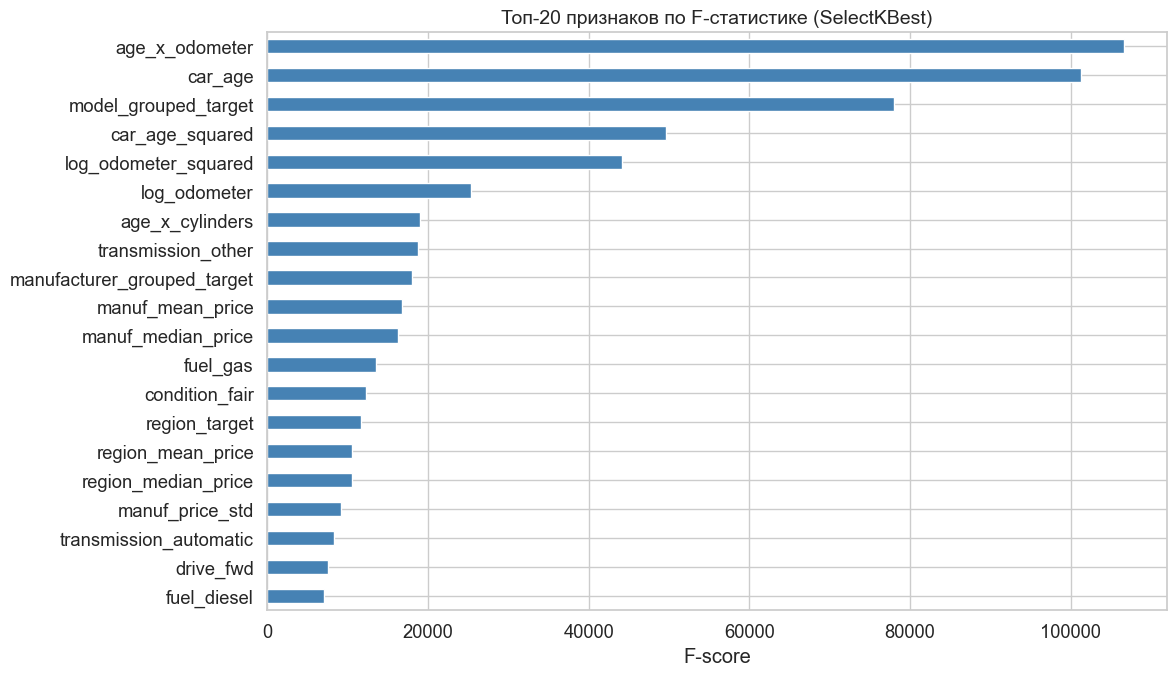

In [20]:
import gc

K = min(50, X_train_clean.shape[1])

# Используем numpy-массивы для экономии памяти при SelectKBest
tr_arr = X_train_clean.values.astype(np.float32)
te_arr = X_test_clean.values.astype(np.float32)

selector = SelectKBest(score_func=f_regression, k=K)
selector.fit(tr_arr, y_train_log.values)  # fit ТОЛЬКО на train!

selected_mask     = selector.get_support()
selected_features = X_train_clean.columns[selected_mask].tolist()

X_train_final = X_train_clean[selected_features].copy()
X_test_final  = X_test_clean[selected_features].copy()
del tr_arr, te_arr; gc.collect()

print(f"Выбрано {len(selected_features)} признаков из {X_train_clean.shape[1]}")
print(f"\nФинальные размерности:")
print(f"  X_train: {X_train_final.shape}")
print(f"  X_test:  {X_test_final.shape}")

# Визуализация F-scores
scores = pd.Series(selector.scores_, index=X_train_clean.columns)
top_scores = scores.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
top_scores.plot.barh(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Топ-20 признаков по F-статистике (SelectKBest)', fontsize=14)
ax.set_xlabel('F-score')
plt.tight_layout()
Path('../reports/figures').mkdir(parents=True, exist_ok=True)
plt.savefig('../reports/figures/feature_selection_scores.png', dpi=150)
plt.show()

<a id='section-11'></a>
## 11. Сохранение результатов

In [21]:
out_path = Path('../data/processed')
out_path.mkdir(parents=True, exist_ok=True)

# Матрицы признаков
X_train_final.to_csv(out_path / 'X_train.csv')
X_test_final.to_csv(out_path / 'X_test.csv')

# Целевые переменные (log-scale)
y_train_log.rename('price').to_csv(out_path / 'y_train.csv', header=True)
y_test_log.rename('price').to_csv(out_path / 'y_test.csv',  header=True)

# Сырые тестовые данные — нужны для анализа ошибок
test_raw.to_csv(out_path / 'test_raw.csv')

# Артефакты трансформации
models_path = Path('../models')
models_path.mkdir(parents=True, exist_ok=True)

joblib.dump(scaler,           models_path / 'scaler.pkl')
joblib.dump(selected_features, models_path / 'feature_names.pkl')
joblib.dump(target_encoders,  models_path / 'target_encoders.pkl')

print("=" * 60)
print("FEATURE ENGINEERING ЗАВЕРШЁН")
print("=" * 60)
print(f"\nСохранено в {out_path}:")
print(f"  X_train.csv   — {X_train_final.shape}")
print(f"  X_test.csv    — {X_test_final.shape}")
print(f"  y_train.csv   — {y_train_log.shape}")
print(f"  y_test.csv    — {y_test_log.shape}")
print(f"  test_raw.csv  — {test_raw.shape}")
print(f"\nМодели/артефакты в {models_path}:")
print(f"  scaler.pkl, feature_names.pkl, target_encoders.pkl")

FEATURE ENGINEERING ЗАВЕРШЁН

Сохранено в ..\data\processed:
  X_train.csv   — (182152, 50)
  X_test.csv    — (78106, 50)
  y_train.csv   — (182152,)
  y_test.csv    — (78106,)
  test_raw.csv  — (78106, 19)

Модели/артефакты в ..\models:
  scaler.pkl, feature_names.pkl, target_encoders.pkl


In [22]:
print("\n" + "=" * 60)
print("ИТОГ FEATURE ENGINEERING")
print("=" * 60)
print(f"\nИсходные данные (train): {df_train.shape[0]:,} строк, {df_train.shape[1]} признаков")
print(f"Финальные признаки:       {X_train_final.shape[1]}")
print()
print("Созданные группы признаков:")
print("  1. car_age                — возраст автомобиля")
print("  2. log_odometer           — логарифм пробега")
print("  3. cylinders_num/flag     — числовое представление цилиндров")
print("  4. OHE-признаки           — condition, transmission, drive, fuel, title_status, type")
print("  5. Target Encoded         — manufacturer_grouped, model_grouped, region")
print("  6. Региональные статистики — mean/median/std цены по региону")
print("  7. Статистики производителя — mean/median/std цены по марке")
print("  8. Полиномиальные         — age^2, odometer^2")
print("  9. Интерактивные          — age×odometer, age×cylinders, ...")
print("\nВсе трансформации — без утечки данных (Data Leakage Free)")
print("Готово к обучению моделей!")


ИТОГ FEATURE ENGINEERING

Исходные данные (train): 182,152 строк, 19 признаков
Финальные признаки:       50

Созданные группы признаков:
  1. car_age                — возраст автомобиля
  2. log_odometer           — логарифм пробега
  3. cylinders_num/flag     — числовое представление цилиндров
  4. OHE-признаки           — condition, transmission, drive, fuel, title_status, type
  5. Target Encoded         — manufacturer_grouped, model_grouped, region
  6. Региональные статистики — mean/median/std цены по региону
  7. Статистики производителя — mean/median/std цены по марке
  8. Полиномиальные         — age^2, odometer^2
  9. Интерактивные          — age×odometer, age×cylinders, ...

Все трансформации — без утечки данных (Data Leakage Free)
Готово к обучению моделей!
